In [240]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import sklearn
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
from sklearn.decomposition import PCA
from imblearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, precision_recall_curve, confusion_matrix, recall_score, make_scorer, mean_squared_error, r2_score, roc_curve, auc, fbeta_score

from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

In [241]:
# Importing and dropping unwanted columns
df = pd.read_csv('/Users/Tudor.Orosz/Documents/School/Thesis/Extract Data Athena/dataset_marketing2.csv')

df = df.drop(["id", "accountid", "account_sales_unit__c", "sales_unit_group__c", "name", "createddate"], axis = 1)

df

,gtm_segment__c,gtm_industry__c,region__c,country_grouping__c,opportunityid,Fill Out Form_Filled Out Form,WBN_Attended,TS_Attended,TS_Visited Booth,Mendix World Session - Attended_Attended,...,TS_Demo Attendee,Other_Added,Other_Unsubscribed,Other_Logged In,TS_Meeting Attendee,Other_Qualified,TS_Filled Out Form,Other_Visited Web Page,Other_Visited booth,CS_Downloaded Asset
0,MFI,Automotive and Transportation,EMEA - Industry,UKI,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,MFI,Semiconductor,US - Industry,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,MXD,Business Services,US - Diversified,US,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,MXD,Business Services,EMEA - REV,Benelux,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,MFI,Industrial Machinery and Heavy Equipment,EMEA - REV,Middle East,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78515,MXD,Insurance,US - Insurance,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78516,MXD,Business Services,US - Diversified,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78517,MXD,Business Services,US - Diversified,US,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
78518,MXD,Business Services,EMEA - REV,Middle East,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [242]:
def get_zero_columns(dataframe):
    zero_columns = []
    for column in dataframe.columns:
        if all(dataframe[column] == 0):
            zero_columns.append(column)
    return zero_columns

# Get columns with only 0's
zero_columns = get_zero_columns(df)

# Print the zero columns
print("Columns with only 0's:", zero_columns)

def remove_zero_columns(dataframe, zero_columns):
    dataframe.drop(zero_columns, axis=1, inplace=True)
    return dataframe
# Remove zero columns
df = remove_zero_columns(df, zero_columns)

Columns with only 0's: ['Other_MQL', 'Other_Responded Negative', 'Other_Downloaded from App Store', 'Other_Deployed an App', 'Other_01-Signed Up', 'TS_Filled Out Form', 'Other_Visited Web Page', 'Other_Visited booth', 'CS_Downloaded Asset']


In [243]:
# One hot encoding the categorical cols

categorical_cols = ['gtm_segment__c', 'gtm_industry__c', 'region__c', 'country_grouping__c']
df_encoded = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, prefix_sep=' ', dummy_na=False)
df_encoded = df_encoded.astype(int)
# Display the resulting dataframe
df = df_encoded
df_encoded

,opportunityid,Fill Out Form_Filled Out Form,WBN_Attended,TS_Attended,TS_Visited Booth,Mendix World Session - Attended_Attended,Mendix World Session - Attended On-Demand_Attended On-Demand,WBN_Attended On-Demand,LE_Attended,WBN_Attended On-demand,...,country_grouping__c Japan,country_grouping__c Middle East,country_grouping__c Nordics,country_grouping__c RoE,country_grouping__c SEA,country_grouping__c South Africa,country_grouping__c South Korea,country_grouping__c Spain,country_grouping__c UKI,country_grouping__c US
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
3,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78515,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
78516,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
78517,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
78518,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0


In [244]:
X = df.drop("opportunityid", axis = 1)
y = df.loc[:, ["opportunityid"]]

In [245]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train2, X_val, y_train2, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=42)

In [246]:
# Define the columns to be one-hot encoded
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

X_numb = X_train.select_dtypes(include=['int64', 'float64'])

indices_pca = [i for i, col in enumerate(X.columns) if col in X_numb.columns]

In [247]:
# Define the pipeline
numeric_transformer = Pipeline(steps=[
    #('imputer', KNNImputer()),
    ('scaler', StandardScaler()), # standardizing
    # ('scaler', MinMaxScaler()), # normalizing
    #('to_df', FunctionTransformer(lambda x: pd.DataFrame(x, columns=X_train2.select_dtypes(include=['int64', 'float64']).columns)))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, X_train2.select_dtypes(include=['int64', 'float64']).columns.tolist()),
        # ('cat', categorical_transformer, categorical_cols),
        # ("pca", PCA(random_state=42, n_components=50), indices_pca),
    ],
    remainder='passthrough'
    )

# Add the upsampler and the pipeline to a machine learning model
model = Pipeline(steps=[
    #('oversampler', oversampler),
    ('preprocessor', preprocessor),
    ('regressor', LGBMClassifier(random_state=42, metric = "recall",importance_type='gain'))
])

parameters = {
    'regressor__n_estimators': [100, 500, 1000],
    'regressor__max_depth': [3, 5, 7],  # -1 represents no limit
    'regressor__learning_rate': [0.01, 0.1, 0.3, 0.5],
    #'regressor__num_leaves': [15, 31, 63, 127],
    #'regressor__min_child_samples': [1, 20, 50, 100],
    #'regressor__reg_alpha': [0, 0.1, 0.5, 1.0],
    #'regressor__reg_lambda': [0, 0.1, 0.5, 1.0]
}

In [248]:
# Set up the grid search object
grid_search = GridSearchCV(model, parameters, cv=10, scoring=make_scorer(recall_score))

In [249]:
# Fit the grid search object to the training data
grid_search.fit(X_train2, y_train2.values.ravel())

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('num',
                                                                         Pipeline(steps=[('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Fill '
                                                                          'Out '
                                                                          'Form_Filled '
                                                                          'Out '
                                                                          'Form',
                                                                          'WBN_Attended',
                                                                          'TS_Attended',
                                                                          'TS_Visited '
                                                                          'Booth',
                                                                          'Mendix '
                                                                          'World '
                                                                          'Session '
                                                                          '- '
                                                                          'Attended_Attended',
                                                                          'Mendix '
                                                                          'World '
                                                                          'Session '
                                                                          '- '
                                                                          'Attended '
                                                                          'On-Demand...
                                                                          'Download',
                                                                          'CS_Third '
                                                                          'Party '
                                                                          'Download',
                                                                          'Other_Converted',
                                                                          'Drift_Downloaded '
                                                                          'Asset',
                                                                          'Other_Engaged', ...])])),
                                       ('regressor',
                                        LGBMClassifier(importance_type='gain',
                                                       metric='recall',
                                                       random_state=42))]),
             param_grid={'regressor__learning_rate': [0.01, 0.1, 0.3, 0.5],
                         'regressor__max_depth': [3, 5, 7],
                         'regressor__n_estimators': [100, 500, 1000]},
             scoring=make_scorer(recall_score))

In [250]:
# Get the best parameters from the grid search
best_params = grid_search.best_params_
print(best_params)

{'regressor__learning_rate': 0.5, 'regressor__max_depth': 7, 'regressor__n_estimators': 1000}


In [251]:
y_pred = grid_search.predict(X_val)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [252]:
y_proba = grid_search.predict_proba(X_val)
y_pred_new = (y_proba[:, 1] > 0.06).astype(int)

In [253]:
# Compute the confusion matrix
cm = confusion_matrix(y_val, y_pred_new)

# Print the confusion matrix with labels
print("Confusion matrix:")
print("           Predicted")
print("           0   1")
print("Actual 0  ", cm[0][0], " ", cm[0][1])
print("       1  ", cm[1][0], " ", cm[1][1])

Confusion matrix:
           Predicted
           0   1
Actual 0   10265   4804
       1   387   1034


In [254]:
# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred_new)

# Extract the true negatives, false positives, false negatives, and true positives
tn, fp, fn, tp = cm.ravel()

# Calculate accuracy, specificity, and sensitivity
accuracy = (tp + tn) / (tp + tn + fp + fn)
specificity = tp / (tp + fp)
sensitivity = tp / (tp + fn)

# Print the results
print(f"Accuracy: {accuracy:.2f}")
print(f"Specificity: {specificity:.2f}")
print(f"Sensitivity: {sensitivity:.2f}")

Accuracy: 0.69
Specificity: 0.18
Sensitivity: 0.73


In [255]:
# Calculate the F1 score
f1 = f1_score(y_val, y_pred_new)
print(f"F1 score: {f1:.2f}")

# Calculate the F2 score
f2 = fbeta_score(y_val, y_pred_new, beta=2)
print(f"F2 score: {f2:.2f}")

# Calculate the AUC
auc = roc_auc_score(y_val, y_proba[:, 1])
print(f"AUC: {auc:.2f}")

F1 score: 0.28
F2 score: 0.45
AUC: 0.76


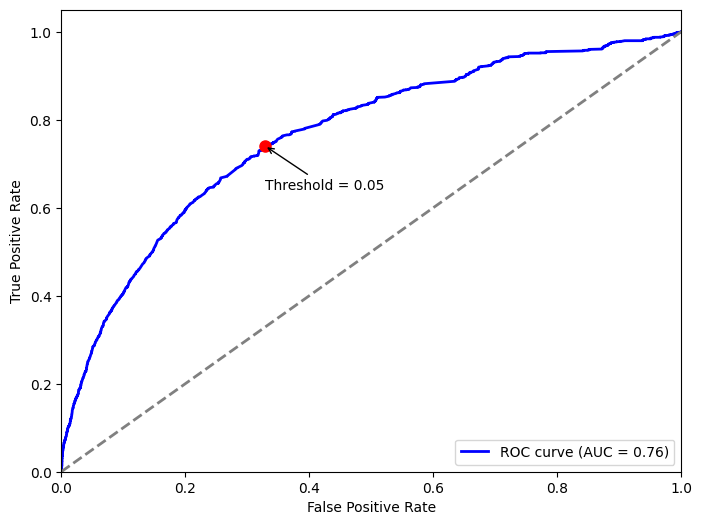

In [270]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Compute ROC curve and AUC
fpr, tpr, thresholds_roc = roc_curve(y_val, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

# Compute Precision-Recall curve and AUC
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_proba[:, 1])
pr_auc = auc(recall, precision)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Plot threshold on ROC curve
best_roc_threshold_idx = np.argmax(tpr - fpr)
best_roc_threshold = thresholds_roc[best_roc_threshold_idx]
plt.plot(fpr[best_roc_threshold_idx], tpr[best_roc_threshold_idx], 'ro', markersize=8)
plt.annotate(f'Threshold = {best_roc_threshold:.2f}', xy=(fpr[best_roc_threshold_idx], tpr[best_roc_threshold_idx]),
             xytext=(fpr[best_roc_threshold_idx], tpr[best_roc_threshold_idx] - 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.show()

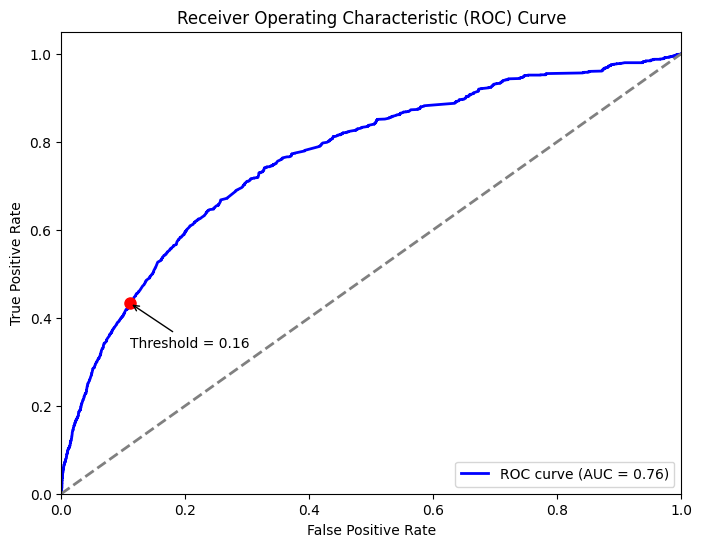

In [257]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve, f1_score

# Compute ROC curve and AUC
fpr, tpr, thresholds_roc = roc_curve(y_val, y_proba[:, 1])
roc_auc = auc(fpr, tpr)

# Compute Precision-Recall curve and AUC
precision, recall, thresholds_pr = precision_recall_curve(y_val, y_proba[:, 1])
pr_auc = auc(recall, precision)

# Compute F1 score for each threshold
f1_scores = 2 * (precision * recall) / (precision + recall)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# Find the threshold with the best F1 score
best_f1_index = np.nanargmax(f1_scores)
best_f1_threshold = thresholds_pr[best_f1_index]

# Calculate the true positive rate (TPR) and false positive rate (FPR) for the best F1 threshold
y_pred_f1 = (y_proba[:, 1] >= best_f1_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_val, y_pred_f1).ravel()
f1_tpr = tp / (tp + fn)
f1_fpr = fp / (fp + tn)

# Plot threshold on ROC curve
plt.plot(f1_fpr, f1_tpr, 'ro', markersize=8)
plt.annotate(f'Threshold = {best_f1_threshold:.2f}', xy=(f1_fpr, f1_tpr),
             xytext=(f1_fpr, f1_tpr - 0.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'))

plt.show()

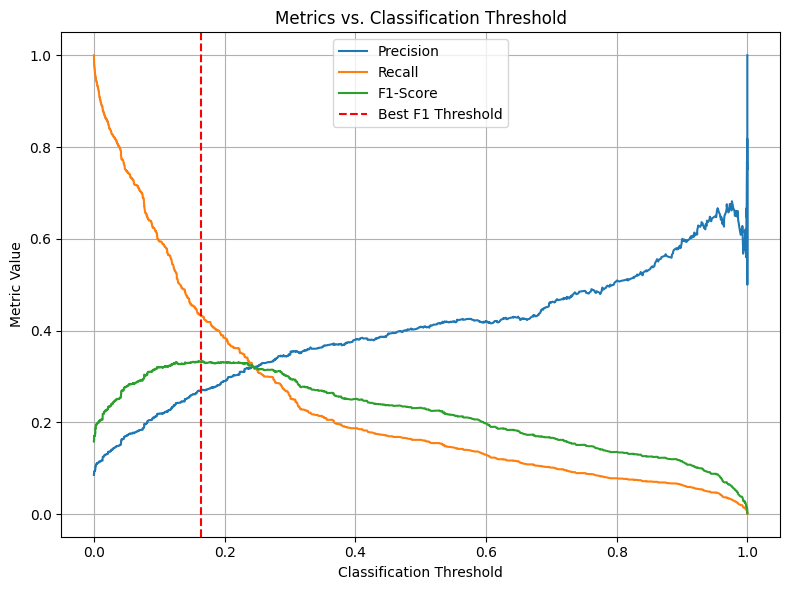

Best F1 Threshold: 0.16
F1-Score at Best Threshold: 0.33


In [258]:
import numpy as npy
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_proba[:, 1])
f1_scores = 2 * (precision * recall) / (precision + recall)

# Calculate AUC
auc = roc_auc_score(y_val, y_proba[:, 1])

# Find the threshold that maximizes the F1-score
best_f1_score_idx = npy.argmax(f1_scores)
best_f1_threshold = thresholds[best_f1_score_idx]

# Plot precision, recall, AUC, and F1-score
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.axvline(x=best_f1_threshold, color='r', linestyle='--', label='Best F1 Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title('Metrics vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the best F1 threshold and its corresponding F1-score
print(f"Best F1 Threshold: {best_f1_threshold:.2f}")
print(f"F1-Score at Best Threshold: {f1_scores[best_f1_score_idx]:.2f}")

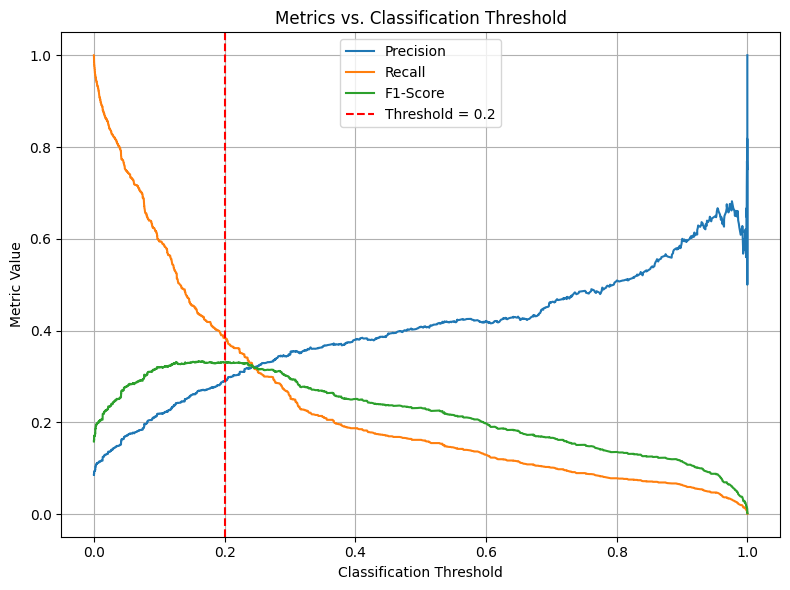

In [259]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_proba[:, 1])
f1_scores = 2 * (precision * recall) / (precision + recall)

# Calculate AUC
auc = roc_auc_score(y_val, y_proba[:, 1])

# Plot precision, recall, AUC, and F1-score
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.axvline(x=0.2, color='r', linestyle='--', label='Threshold = 0.2')  # Example threshold
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title('Metrics vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

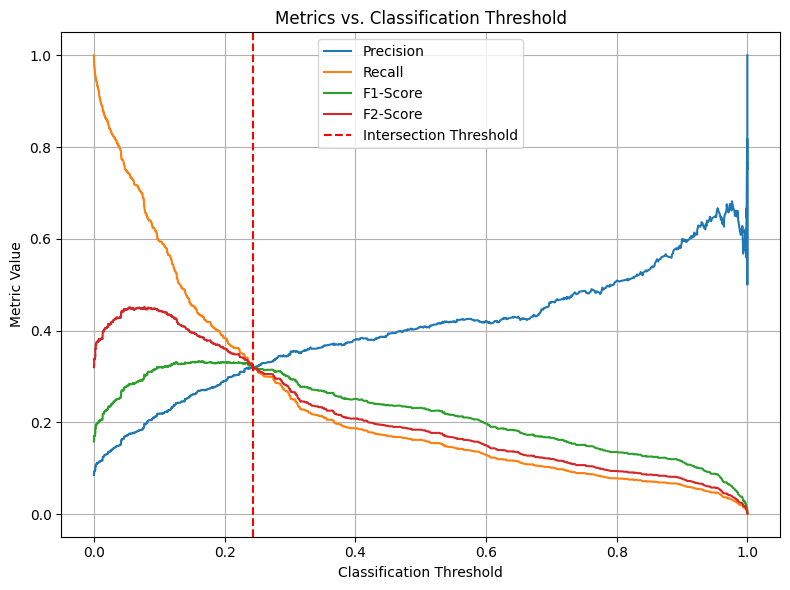

Intersection Threshold: 0.24


In [260]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_auc_score, f1_score

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_proba[:, 1])
f1_scores = 2 * (precision * recall) / (precision + recall)
f2_scores = (1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall)

# Calculate AUC
auc = roc_auc_score(y_val, y_proba[:, 1])

# Find the threshold at the intersection point
differences = np.abs(precision - recall)
intersection_idx = np.argmin(differences)
intersection_threshold = thresholds[intersection_idx]

# Plot precision, recall, AUC, F1-score, and F2-score
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.plot(thresholds, f2_scores[:-1], label='F2-Score')
plt.axvline(x=intersection_threshold, color='r', linestyle='--', label='Intersection Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title('Metrics vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the intersection threshold
print(f"Intersection Threshold: {intersection_threshold:.2f}")

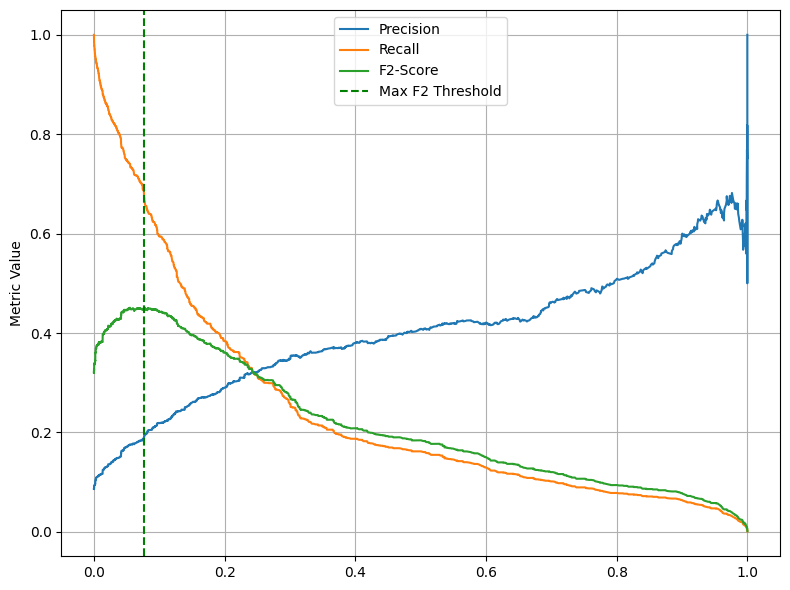

Max F2 Threshold: 0.08


In [269]:
# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_proba[:, 1])
f1_scores = 2 * (precision * recall) / (precision + recall)
f2_scores = (1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall)

# Calculate AUC
auc = roc_auc_score(y_val, y_proba[:, 1])

# Find the threshold that maximizes the F2-score
max_f2_idx = np.argmax(f2_scores)
max_f2_threshold = thresholds[max_f2_idx]

# Plot precision, recall, AUC, F1-score, and F2-score
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
#plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.plot(thresholds, f2_scores[:-1], label='F2-Score')
plt.axvline(x=max_f2_threshold, color='g', linestyle='--', label='Max F2 Threshold')
#plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
#plt.title('Metrics vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the maximum F2 threshold
print(f"Max F2 Threshold: {max_f2_threshold:.2f}")

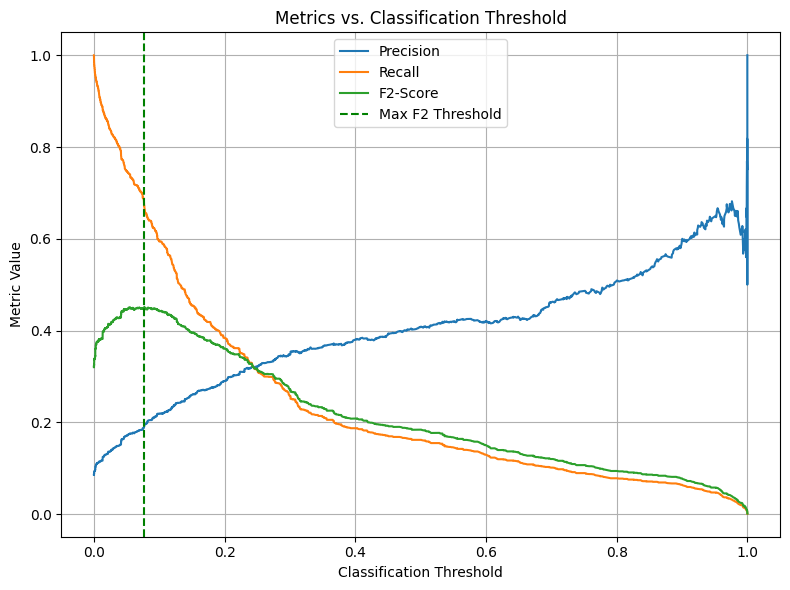

Max F2 Threshold: 0.08


In [262]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, fbeta_score

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_val, y_proba[:, 1])
f1_scores = 2 * (precision * recall) / (precision + recall)
f2_scores = (1 + 2**2) * (precision * recall) / ((2**2 * precision) + recall)

# Calculate AUC
auc = roc_auc_score(y_val, y_proba[:, 1])

# Find the threshold that maximizes the F2-score
max_f2_idx = np.nanargmax(f2_scores)
max_f2_threshold = thresholds[max_f2_idx]

# Plot precision, recall, AUC, F1-score, and F2-score
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
#plt.plot(thresholds, f1_scores[:-1], label='F1-Score')
plt.plot(thresholds, f2_scores[:-1], label='F2-Score')
plt.axvline(x=max_f2_threshold, color='g', linestyle='--', label='Max F2 Threshold')
plt.xlabel('Classification Threshold')
plt.ylabel('Metric Value')
plt.title('Metrics vs. Classification Threshold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the maximum F2 threshold
print(f"Max F2 Threshold: {max_f2_threshold:.2f}")

## Feature importance

In [263]:
# Feature importance
hd = list(X_train2.columns)

# Calculate the importances
feature_importances = grid_search.best_estimator_.named_steps["regressor"].feature_importances_
feature_scores = list(zip(hd, feature_importances))
df_feature_importances = pd.DataFrame(feature_scores, columns=['Feature', 'Importance Score (%)'])

# Should add up to 100%
total_score = df_feature_importances['Importance Score (%)'].sum()
print(total_score)

13476.89183121968


In [264]:
# Import and view dataframe
# df_feature_importances.to_csv('feature_importances.csv', index=False)
df_feature_importances
# --------------------------------end feature importance------------------------------

,Feature,Importance Score (%)
0,Fill Out Form_Filled Out Form,2157.490784
1,WBN_Attended,949.365832
2,TS_Attended,186.379273
3,TS_Visited Booth,219.611292
4,Mendix World Session - Attended_Attended,409.219478
...,...,...
98,country_grouping__c South Africa,20.844479
99,country_grouping__c South Korea,0.000000
100,country_grouping__c Spain,11.569648
101,country_grouping__c UKI,192.602112


In [265]:
df_filtered = df_feature_importances[df_feature_importances['Importance Score (%)'] != 0]
df_filtered = df_filtered.sort_values('Importance Score (%)', ascending=False)

In [266]:
df_filtered['Actual Percentage'] = df_filtered['Importance Score (%)'] / df_filtered['Importance Score (%)'].sum() * 100

In [271]:
df_filtered = df_filtered.drop('Importance Score (%)', axis=1)
df_filtered = df_filtered.rename(columns={'Actual Percentage': 'Importance Score (%)'})

In [275]:
df_filtered

,Feature,Importance Score (%)
0,Fill Out Form_Filled Out Form,16.008816
1,WBN_Attended,7.044398
67,gtm_industry__c Software & IT,5.963152
51,gtm_industry__c Electronics,5.698685
9,Platform Signups_Filled Out Form,5.292902
...,...,...
100,country_grouping__c Spain,0.085848
25,Other_Third Party Download,0.078965
14,Other_Attended,0.058980
41,gtm_segment__c CH,0.048268


In [276]:
df_filtered.to_csv('feature_importances_light.csv', index=False)